In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import copy
from scipy.stats import wilcoxon, mannwhitneyu
import pickle as pkl
import random

import nibabel as nib

import matplotlib.pyplot as plt 
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=FutureWarning)

/Users/suvodeepmajumder/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/suvodeepmajumder/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
def load_unet_result(path, _print):
    unet_df = pd.read_csv(path, index_col = 'Unnamed: 0')
    index_values = []
    for _index in unet_df.index:
        index_values.append(_index.split('-seg')[0])

    unet_df.index = index_values  
    unet_df.drop(['WT jaccard', 'TC jaccard', 'ET jaccard'], axis = 1, inplace = True)
    summary_unet_df = pd.DataFrame(zip(unet_df.mean().values.tolist(), 
                                       unet_df.std().values.tolist()), 
                                   columns = ['mean', 'std'], index = unet_df.columns)
    if _print:
        print("****UNet******")
        print(summary_unet_df)
    return summary_unet_df, unet_df

def load_nnunet_result(path, _print):
    with open(path, 'r') as file:
        data = json.load(file)

    WT = []
    TC = []
    ET = []
    file_name = []
    for case in data['metric_per_case']:
        WT.append(case['metrics']['(2, 1, 3)']['Dice'])
        TC.append(case['metrics']['(2, 3)']['Dice'])
        ET.append(case['metrics']['(3,)']['Dice'])
        file_name.append(case['reference_file'].split('/')[-1].split('.')[0])

    nnunet_df = pd.DataFrame(zip(WT, TC, ET), columns = ['WT dice', 'TC dice', 'ET dice'], 
                             index = file_name)
    summary_nnunet_df = pd.DataFrame(zip(nnunet_df.mean().values.tolist(), 
                                       nnunet_df.std().values.tolist()), 
                                   columns = ['mean', 'std'], index = nnunet_df.columns)
    if _print:
        print("****nnUNet******")
        print(summary_nnunet_df)
    return summary_nnunet_df, nnunet_df

def load_TransBTS_result(path, _print):
    with open(path, 'r') as file:
        data = json.load(file)

    WT = []
    TC = []
    ET = []
    file_name = []
    for case_id in data.keys():
        case = data[case_id]
        WT.append(case['WT'][0])
        TC.append(case['TC'][0])
        ET.append(case['ET'][0])
        file_name.append(case_id)

    TransBTS_df = pd.DataFrame(zip(WT, TC, ET), columns = ['WT dice', 'TC dice', 'ET dice'], 
                             index = file_name)
    summary_TransBTS_df = pd.DataFrame(zip(TransBTS_df.mean().values.tolist(), 
                                       TransBTS_df.std().values.tolist()), 
                                   columns = ['mean', 'std'], index = TransBTS_df.columns)
    if _print:
        print("****TransBTS******")
        print(summary_TransBTS_df)
    return summary_TransBTS_df, TransBTS_df

def read_radiomics_results(analysis_type, location):
    file_name = '../Results/Analysis_Results/Radiomics/' + location + '/' + analysis_type + '.pkl'
    with open(file_name, 'rb') as f:
        results = pkl.load(f)
    return results

def read_results(_print=True):
    path = '../Results/Result/Vanilla_Unet/Unet_test_dice.csv'
    summary_unet_df, unet_df = load_unet_result(path, _print)

    path = '../Results/Result/nnUnet/nnUNetTrainer/summary.json'
    summary_da_nnunet_df, nnunet_da_df = load_nnunet_result(path, _print)

    path = '../Results/Result/nnUnet/nnUNetTrainerNoDA/summary.json'
    summary_noda_nnunet_df, nnunet_noda_df = load_nnunet_result(path, _print)

    path = '../Results/Result/TransBTS/submission/TransBTS2023-11-03/TransBTS_summary.json'
    summary_TransBTS_df, TransBTS_df = load_TransBTS_result(path, _print)
    return unet_df, nnunet_noda_df, nnunet_da_df, TransBTS_df


def get_dataset(performance_df, analysis_types, location):
    results_df = performance_df
    for analysis_type in analysis_types:
        try:
            radiomics_results_df = read_radiomics_results(analysis_type, location)
        except Exception as e:
            print(e)
            continue
        properties = {}
        property_df = pd.DataFrame()
        for i in range(len(radiomics_results_df.keys())):
            key = list(radiomics_results_df.keys())[i]
            properties[i] = key

        for i in range(len(properties)):
            selected_property = properties[i]

            property_result_df = pd.DataFrame.from_dict(radiomics_results_df[selected_property], 
                                                        orient = 'index').astype(float)
            new_col = []
            for col in property_result_df.columns:
                new_col.append(selected_property + '_' + col + '_' + analysis_type)
            property_result_df.columns = new_col
            results_df = pd.merge(property_result_df, 
                           results_df, 
                           left_index=True, 
                           right_index=True)
#             print(property_result_df.shape)

    remove_index = results_df.sort_values(['WT dice'])[0:20].index
    low_examples = results_df.loc[remove_index]
    results_df.drop(['WT dice', 'TC dice', 'ET dice'], axis=1, inplace=True)
    # results_df.drop(remove_index, axis = 0, inplace=True)
    
    return results_df, low_examples

def get_overlaps(unet_df, TransBTS_df, nnunet_noda_df, WT_dice_threshold, TC_dice_threshold, ET_dice_threshold):
    unet_df_sub = unet_df[(unet_df['WT dice'] < WT_dice_threshold) 
                          & (unet_df['TC dice'] < TC_dice_threshold) 
                          & (unet_df['ET dice'] < ET_dice_threshold)]
    
    TransBTS_df_sub = TransBTS_df[(TransBTS_df['WT dice'] < WT_dice_threshold) 
                          & (TransBTS_df['TC dice'] < TC_dice_threshold) 
                          & (TransBTS_df['ET dice'] < ET_dice_threshold)]
    
    nnunet_noda_df_sub = nnunet_noda_df[(nnunet_noda_df['WT dice'] < WT_dice_threshold) 
                          & (nnunet_noda_df['TC dice'] < TC_dice_threshold) 
                          & (nnunet_noda_df['ET dice'] < ET_dice_threshold)]

    unet_df_sub_subjects = unet_df_sub.index.values.tolist()
    TransBTS_df_sub_subjects = TransBTS_df_sub.index.values.tolist()
    nnunet_noda_df_sub_subjects = nnunet_noda_df_sub.index.values.tolist()

    all_overlaps = list(set(unet_df_sub_subjects) & set(TransBTS_df_sub_subjects) & set(nnunet_noda_df_sub_subjects))
#     print('all overlap', len(all_overlaps), unet_df_sub.shape, nnunet_noda_df_sub.shape)

    unet_nnunet_overlaps = list(set(unet_df_sub_subjects) & set(nnunet_noda_df_sub_subjects))
#     print('unet-nnunet overlap', len(unet_nnunet_overlaps))

    unet_TransBTS_overlaps = list(set(unet_df_sub_subjects) & set(TransBTS_df_sub_subjects))
#     print('unet-TransBTS overlap', len(unet_TransBTS_overlaps))

    nnunet_TransBTS_overlaps = list(set(TransBTS_df_sub_subjects) & set(nnunet_noda_df_sub_subjects))
#     print('nnunet-TransBTS overlap', len(nnunet_TransBTS_overlaps))
    
    return all_overlaps, unet_nnunet_overlaps

In [3]:
analysis_types = ['firstorder', 'shape' , 'size',
                  'glcm_1', 'glcm_5', 'glcm_10', 
                  'gldm_1', 'gldm_5', 'gldm_10', 
                  'glrlm', 'glszm', 'intensity', 
                  'ngtdm_1', 'ngtdm_5','ngtdm_10']

WT_dice_threshold= 0.91
TC_dice_threshold= 0.86
ET_dice_threshold= 0.85

unet_df, nnunet_noda_df, nnunet_da_df, TransBTS_df = read_results(False)
performance_df = unet_df

all_overlaps, unet_nnunet_overlaps = get_overlaps(unet_df, 
                                                TransBTS_df, 
                                                nnunet_noda_df, 
                                                WT_dice_threshold, 
                                                TC_dice_threshold, 
                                                ET_dice_threshold)

In [4]:
location = 'Tumor_WT'
Subset_Features = []

analysis_types = ['gldm_10']
glcm_df, _ = get_dataset(performance_df, analysis_types, location)

WT_results_df = pd.merge(glcm_df, 
                       performance_df, 
                       left_index=True, 
                       right_index=True)


WT_results_df = WT_results_df.T.drop_duplicates()
WT_results_df = WT_results_df.T
WT_results_df = WT_results_df.dropna()


WT_unet_df_bad = WT_results_df[(WT_results_df['WT dice'] < WT_dice_threshold) 
                          & (WT_results_df['TC dice'] < TC_dice_threshold) 
                          & (WT_results_df['ET dice'] < ET_dice_threshold)]
WT_unet_df_bad = WT_unet_df_bad[WT_unet_df_bad.index.isin(unet_nnunet_overlaps)]
WT_unet_df_bad['dice'] = ['bad']*WT_unet_df_bad.shape[0]

WT_unet_df_good = WT_results_df[(WT_results_df['WT dice'] >= WT_dice_threshold) 
                          & (WT_results_df['TC dice'] >= TC_dice_threshold) 
                          & (WT_results_df['ET dice'] >= ET_dice_threshold)]
WT_unet_df_good['dice'] = ['good']*WT_unet_df_good.shape[0]
WT_unet_df_good.drop(['WT dice','TC dice', 'ET dice'], axis = 1, inplace=True)
WT_results_df.shape

(938, 59)

In [5]:
location = 'Tumor_TC'
Subset_Features = []

analysis_types = ['gldm_10']
glcm_df, _ = get_dataset(performance_df, analysis_types, location)

TC_results_df = pd.merge(glcm_df, 
                       performance_df, 
                       left_index=True, 
                       right_index=True)


TC_results_df = TC_results_df.T.drop_duplicates()
TC_results_df = TC_results_df.T
TC_results_df = TC_results_df.dropna()

TC_unet_df_bad = TC_results_df[(TC_results_df['WT dice'] < WT_dice_threshold) 
                          & (TC_results_df['TC dice'] < TC_dice_threshold) 
                          & (TC_results_df['ET dice'] < ET_dice_threshold)]
TC_unet_df_bad = TC_unet_df_bad[TC_unet_df_bad.index.isin(unet_nnunet_overlaps)]
TC_unet_df_bad['dice'] = ['bad']*TC_unet_df_bad.shape[0]

TC_unet_df_good = TC_results_df[(TC_results_df['WT dice'] >= WT_dice_threshold) 
                          & (TC_results_df['TC dice'] >= TC_dice_threshold) 
                          & (TC_results_df['ET dice'] >= ET_dice_threshold)]
TC_unet_df_good['dice'] = ['good']*TC_unet_df_good.shape[0]
TC_unet_df_good.drop(['WT dice','TC dice', 'ET dice'], axis = 1, inplace=True)
TC_results_df.shape

(928, 59)

In [6]:
location = 'Tumor_ET'
Subset_Features = []

analysis_types = ['gldm_10']
glcm_df, _ = get_dataset(performance_df, analysis_types, location)

ET_results_df = pd.merge(glcm_df, 
                       performance_df, 
                       left_index=True, 
                       right_index=True)

ET_results_df = ET_results_df.T.drop_duplicates()
ET_results_df = ET_results_df.T
ET_results_df = ET_results_df.dropna()

ET_unet_df_bad = ET_results_df[(ET_results_df['WT dice'] < WT_dice_threshold) 
                          & (ET_results_df['TC dice'] < TC_dice_threshold) 
                          & (ET_results_df['ET dice'] < ET_dice_threshold)]
ET_unet_df_bad = ET_unet_df_bad[ET_unet_df_bad.index.isin(unet_nnunet_overlaps)]
ET_unet_df_bad['dice'] = ['bad']*ET_unet_df_bad.shape[0]

ET_unet_df_good = ET_results_df[(ET_results_df['WT dice'] >= WT_dice_threshold) 
                          & (ET_results_df['TC dice'] >= TC_dice_threshold) 
                          & (ET_results_df['ET dice'] >= ET_dice_threshold)]
ET_unet_df_good['dice'] = ['good']*ET_unet_df_good.shape[0]
ET_unet_df_good.drop(['WT dice','TC dice', 'ET dice'], axis = 1, inplace=True)
ET_results_df.shape

(928, 59)

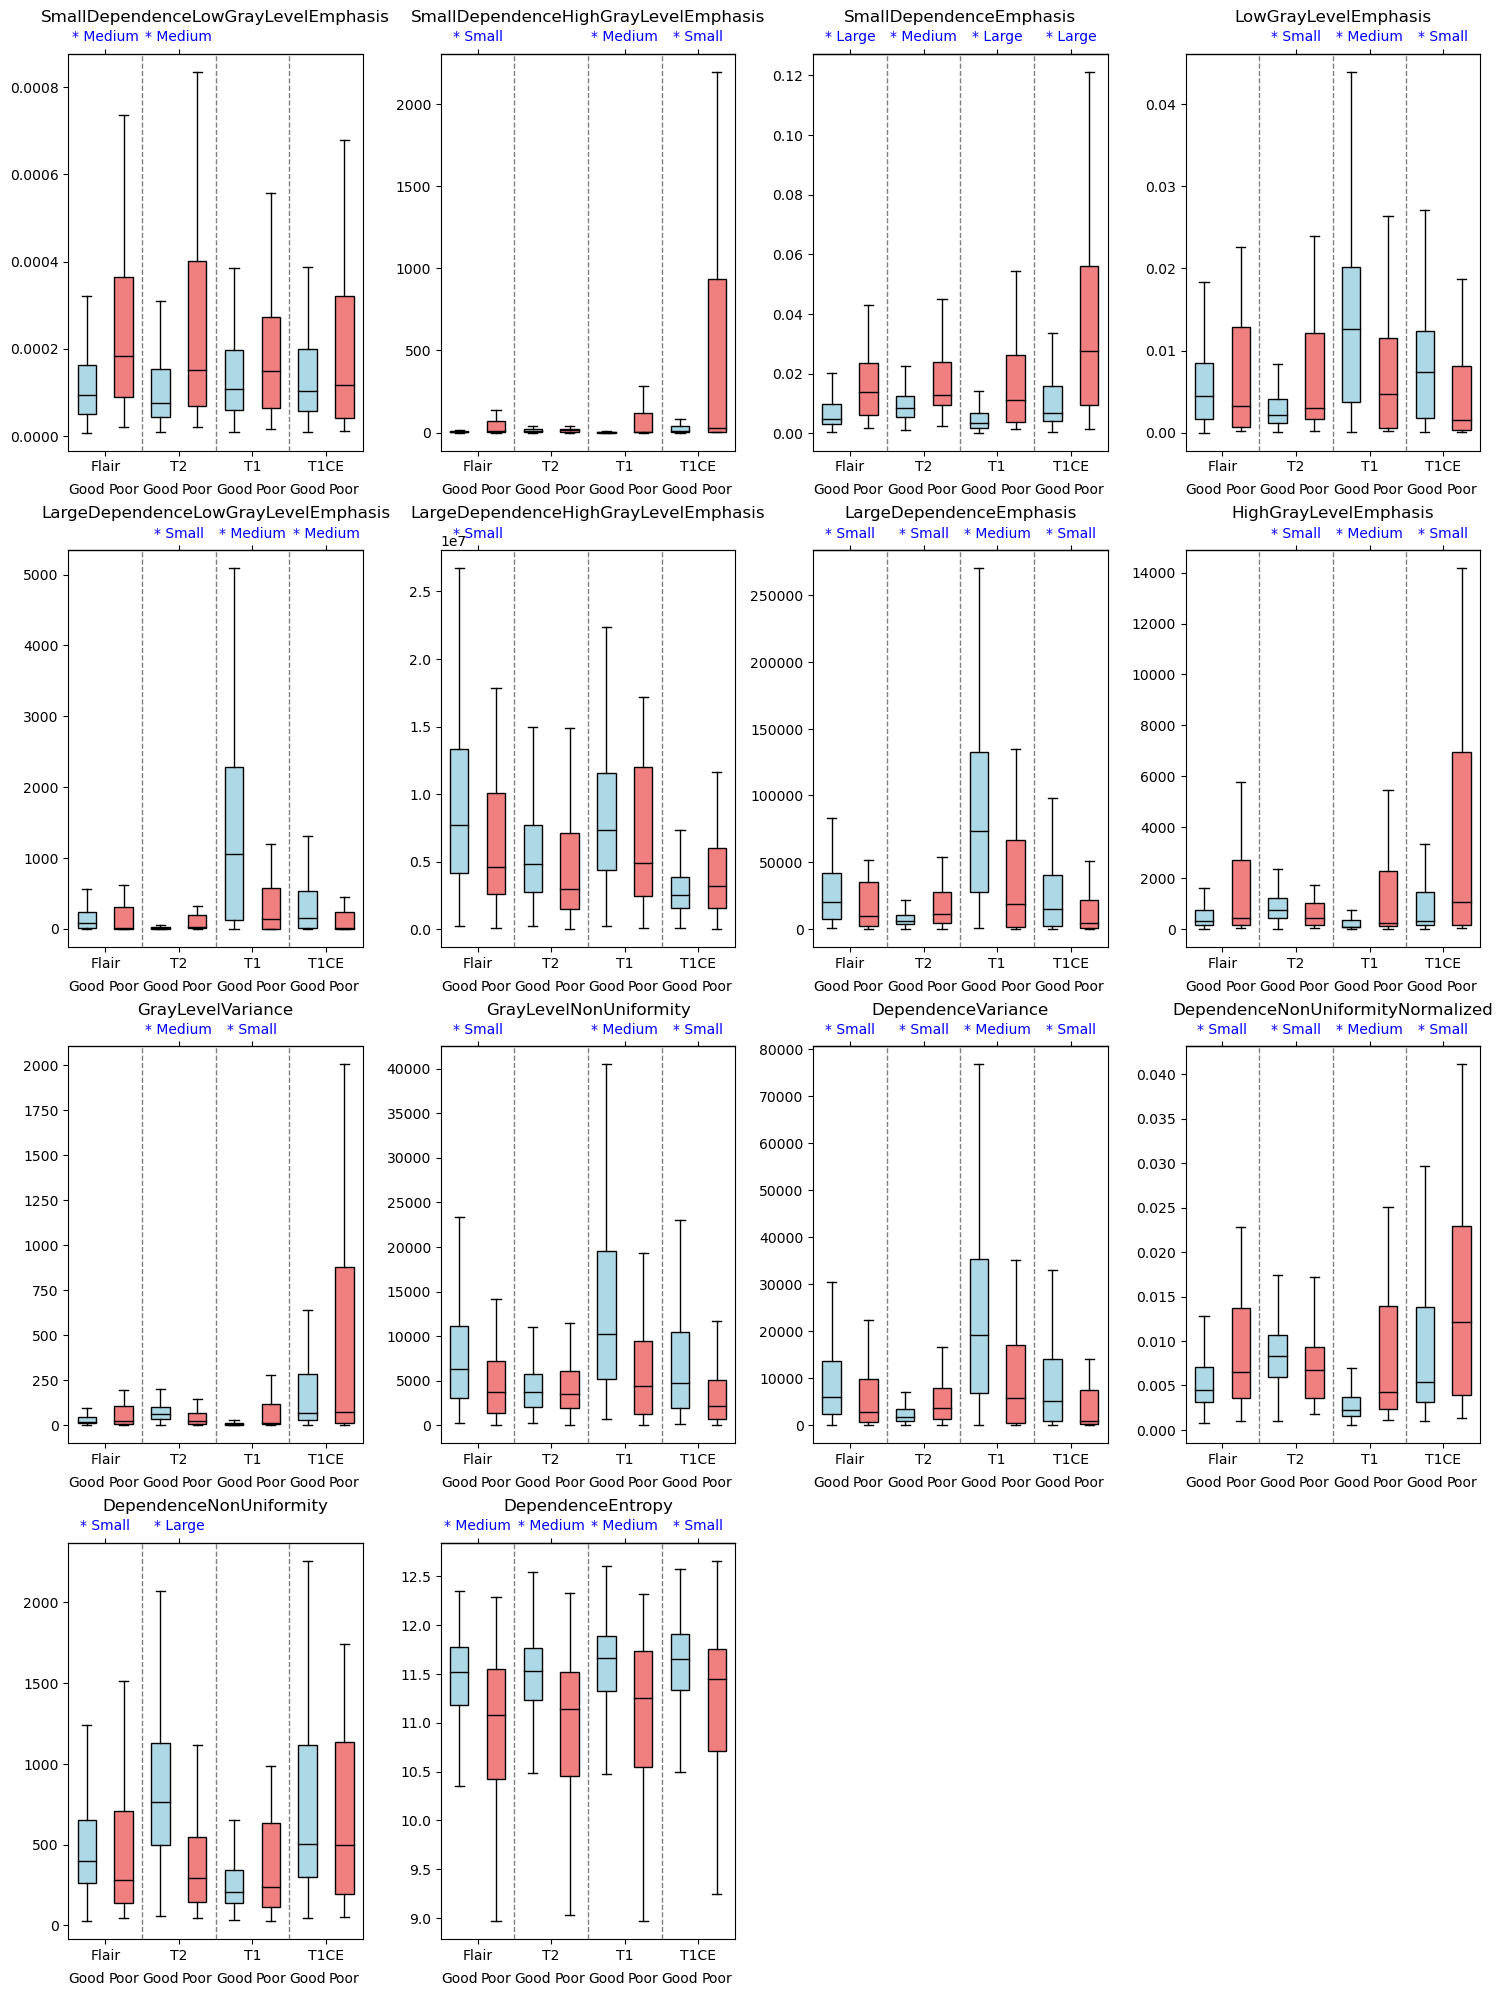

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from scipy.stats import mannwhitneyu
import numpy as np

# Function to convert columns to numeric and skip those that can't be converted
def filter_numeric_columns(df):
    numeric_df = df.apply(pd.to_numeric, errors='coerce')
    return numeric_df.dropna(axis=1, how='all')

# Function to calculate Cliff's delta
def cliffs_delta(x, y):
    n_x = len(x)
    n_y = len(y)
    N_gr = sum(xi > yi for xi in x for yi in y)
    N_ls = sum(xi < yi for xi in x for yi in y)
    return (N_gr - N_ls) / (n_x * n_y)

# Function to categorize effect size based on Cliff's delta
def categorize_effect_size(delta):
    abs_delta = abs(delta)
    if abs_delta < 0.147:
        return 'No'
    elif 0.147 <= abs_delta < 0.33:
        return 'Small'
    elif 0.33 <= abs_delta < 0.474:
        return 'Medium'
    else:
        return 'Large'

# Function to add significance and effect size indicators as a separate xtick on top of the subplots
def add_significance_indicator(axes, data_good, data_bad, x_pos, alpha=0.05):
    # Perform Mann-Whitney U test
    stat, p_value = mannwhitneyu(data_good, data_bad)
    
    # Check if the result is significant
    if p_value < alpha:
        # Calculate Cliff's delta
        delta_value = cliffs_delta(data_good, data_bad)
        # Categorize effect size
        effect_size_category = categorize_effect_size(delta_value)
        
        # Create the label string with significance and effect size
        label = f"* {effect_size_category}"
        
        # Add the new label at the specified position on a secondary x-axis
        axes_secondary = axes.secondary_xaxis('top')
        axes_secondary.set_xticks([x_pos+.5])
        axes_secondary.set_xticklabels([label], rotation=0, ha='center')
        
        # Adjust the color of the labels
        for label in axes_secondary.get_xticklabels():
            text = label.get_text()
            if "*" in text:
                label.set_color('blue')  # Set color for significance
#             if "Large" in text:
#                 label.set_color('blue')  # Set color for effect size

        # Optional: Adjust the label font size for visibility
        for label in axes_secondary.get_xticklabels():
            label.set_fontsize(10)




# Filter the columns to keep only numeric ones
WT_unet_df_good_numeric = filter_numeric_columns(WT_unet_df_good)
WT_unet_df_bad_numeric = filter_numeric_columns(WT_unet_df_bad)
TC_unet_df_good_numeric = filter_numeric_columns(TC_unet_df_good)
TC_unet_df_bad_numeric = filter_numeric_columns(TC_unet_df_bad)
ET_unet_df_good_numeric = filter_numeric_columns(ET_unet_df_good)
ET_unet_df_bad_numeric = filter_numeric_columns(ET_unet_df_bad)


# Generate Feature Names
feature_names = []
for col in ET_results_df.columns[:-3]:
    col = col.split('_')[2]
    if col not in feature_names:
        feature_names.append(col)
        
# feature_names = ['DependenceEntropy', 
#                  'DependenceNonUniformity', 
#                  'SmallDependenceEmphasis', 
#                  'SmallDependenceLowGrayLevelEmphasis']

# Define the number of rows and columns for the grid
n_cols = 4  # Number of columns per row in the grid
plots_per_figure = 16  # Number of plots per figure

# Colors for the box plots
colors = ['lightblue', 'lightcoral'] * 4  # Alternating colors for "Good" and "Bad" for each group

# Labels grouped by categories with "Good" and "Bad" sub-labels
group_labels = ['Flair', 'T2', 'T1', 'T1CE']
sub_labels = ['Good', 'Poor']

# Open a PDF file to save the figures
with PdfPages("../Results/final_figures/GLDM.pdf") as pdf:
    # Generate the plots across multiple figures
    for fig_num in range(len(feature_names) // plots_per_figure + (len(feature_names) % plots_per_figure > 0)):
        start_idx = fig_num * plots_per_figure
        end_idx = min(start_idx + plots_per_figure, len(feature_names))
        
        fig, axes = plt.subplots((end_idx - start_idx) // n_cols + 1, n_cols, figsize=(15, 5 * ((end_idx - start_idx) // n_cols + 1)))
        # Flatten the axes array for easier indexing
        axes = axes.flatten()

        for i, col in enumerate(feature_names):
            box = axes[i].boxplot(
                [
                    WT_unet_df_good_numeric['original_gldm_'+ col + '_flair_' + analysis_types[0]], WT_unet_df_bad_numeric['original_gldm_'+ col + '_flair_' + analysis_types[0]],
                    WT_unet_df_good_numeric['original_gldm_'+ col + '_t2_' + analysis_types[0]], WT_unet_df_bad_numeric['original_gldm_'+ col + '_t2_' + analysis_types[0]],
                    WT_unet_df_good_numeric['original_gldm_'+ col + '_t1_' + analysis_types[0]], WT_unet_df_bad_numeric['original_gldm_'+ col + '_t1_' + analysis_types[0]],
                    WT_unet_df_good_numeric['original_gldm_'+ col + '_t1ce_' + analysis_types[0]], WT_unet_df_bad_numeric['original_gldm_'+ col + '_t1ce_' + analysis_types[0]]
                ],
                patch_artist=True, 
                widths=0.5,
                showfliers=False  # Hide outliers
            )

            # Set colors for the box plot median
            for median in box['medians']:
                median.set_color('black')

            # Set colors for the box plots
            for patch, color in zip(box['boxes'], colors):
                patch.set_facecolor(color)

            # Add significance indicators for each group
            add_significance_indicator(axes[i], 
                                       WT_unet_df_good_numeric['original_gldm_'+ col + '_flair_' + analysis_types[0]], 
                                       WT_unet_df_bad_numeric['original_gldm_'+ col + '_flair_' + analysis_types[0]], 
                                       1)
            add_significance_indicator(axes[i], 
                                       WT_unet_df_good_numeric['original_gldm_'+ col + '_t2_' + analysis_types[0]], 
                                       WT_unet_df_bad_numeric['original_gldm_'+ col + '_t2_' + analysis_types[0]], 
                                       3)
            add_significance_indicator(axes[i], 
                                       WT_unet_df_good_numeric['original_gldm_'+ col + '_t1_' + analysis_types[0]], 
                                       WT_unet_df_bad_numeric['original_gldm_'+ col + '_t1_' + analysis_types[0]], 
                                       5)
            add_significance_indicator(axes[i], 
                                       WT_unet_df_good_numeric['original_gldm_'+ col + '_t1ce_' + analysis_types[0]], 
                                       WT_unet_df_bad_numeric['original_gldm_'+ col + '_t1ce_' + analysis_types[0]], 
                                       7)

            # Set the x-axis with grouped labels
            axes[i].set_xticks([1.5, 3.5, 5.5, 7.5])
            axes[i].set_xticklabels(group_labels)

            # Add sub-labels under each group
            for j, x in enumerate([1, 2, 3, 4, 5, 6, 7, 8]):
                axes[i].text(
                    x, axes[i].get_ylim()[0] - (axes[i].get_ylim()[1] - axes[i].get_ylim()[0]) * 0.1, 
                    sub_labels[j % 2], ha='center', va='center', fontsize=10
                )

            # Add dotted lines to separate the groups
            for pos in [2.5, 4.5, 6.5]:
                axes[i].axvline(x=pos, color='gray', linestyle='--', linewidth=1)

            col_title = col
            axes[i].set_title(f'{col_title}')

        # Remove any empty subplots
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()

        # Save the current figure to the PDF
        pdf.savefig(fig)
        plt.show()
        plt.close(fig)  # Close the figure to free memory

    # The PDF will automatically be closed here when exiting the with block


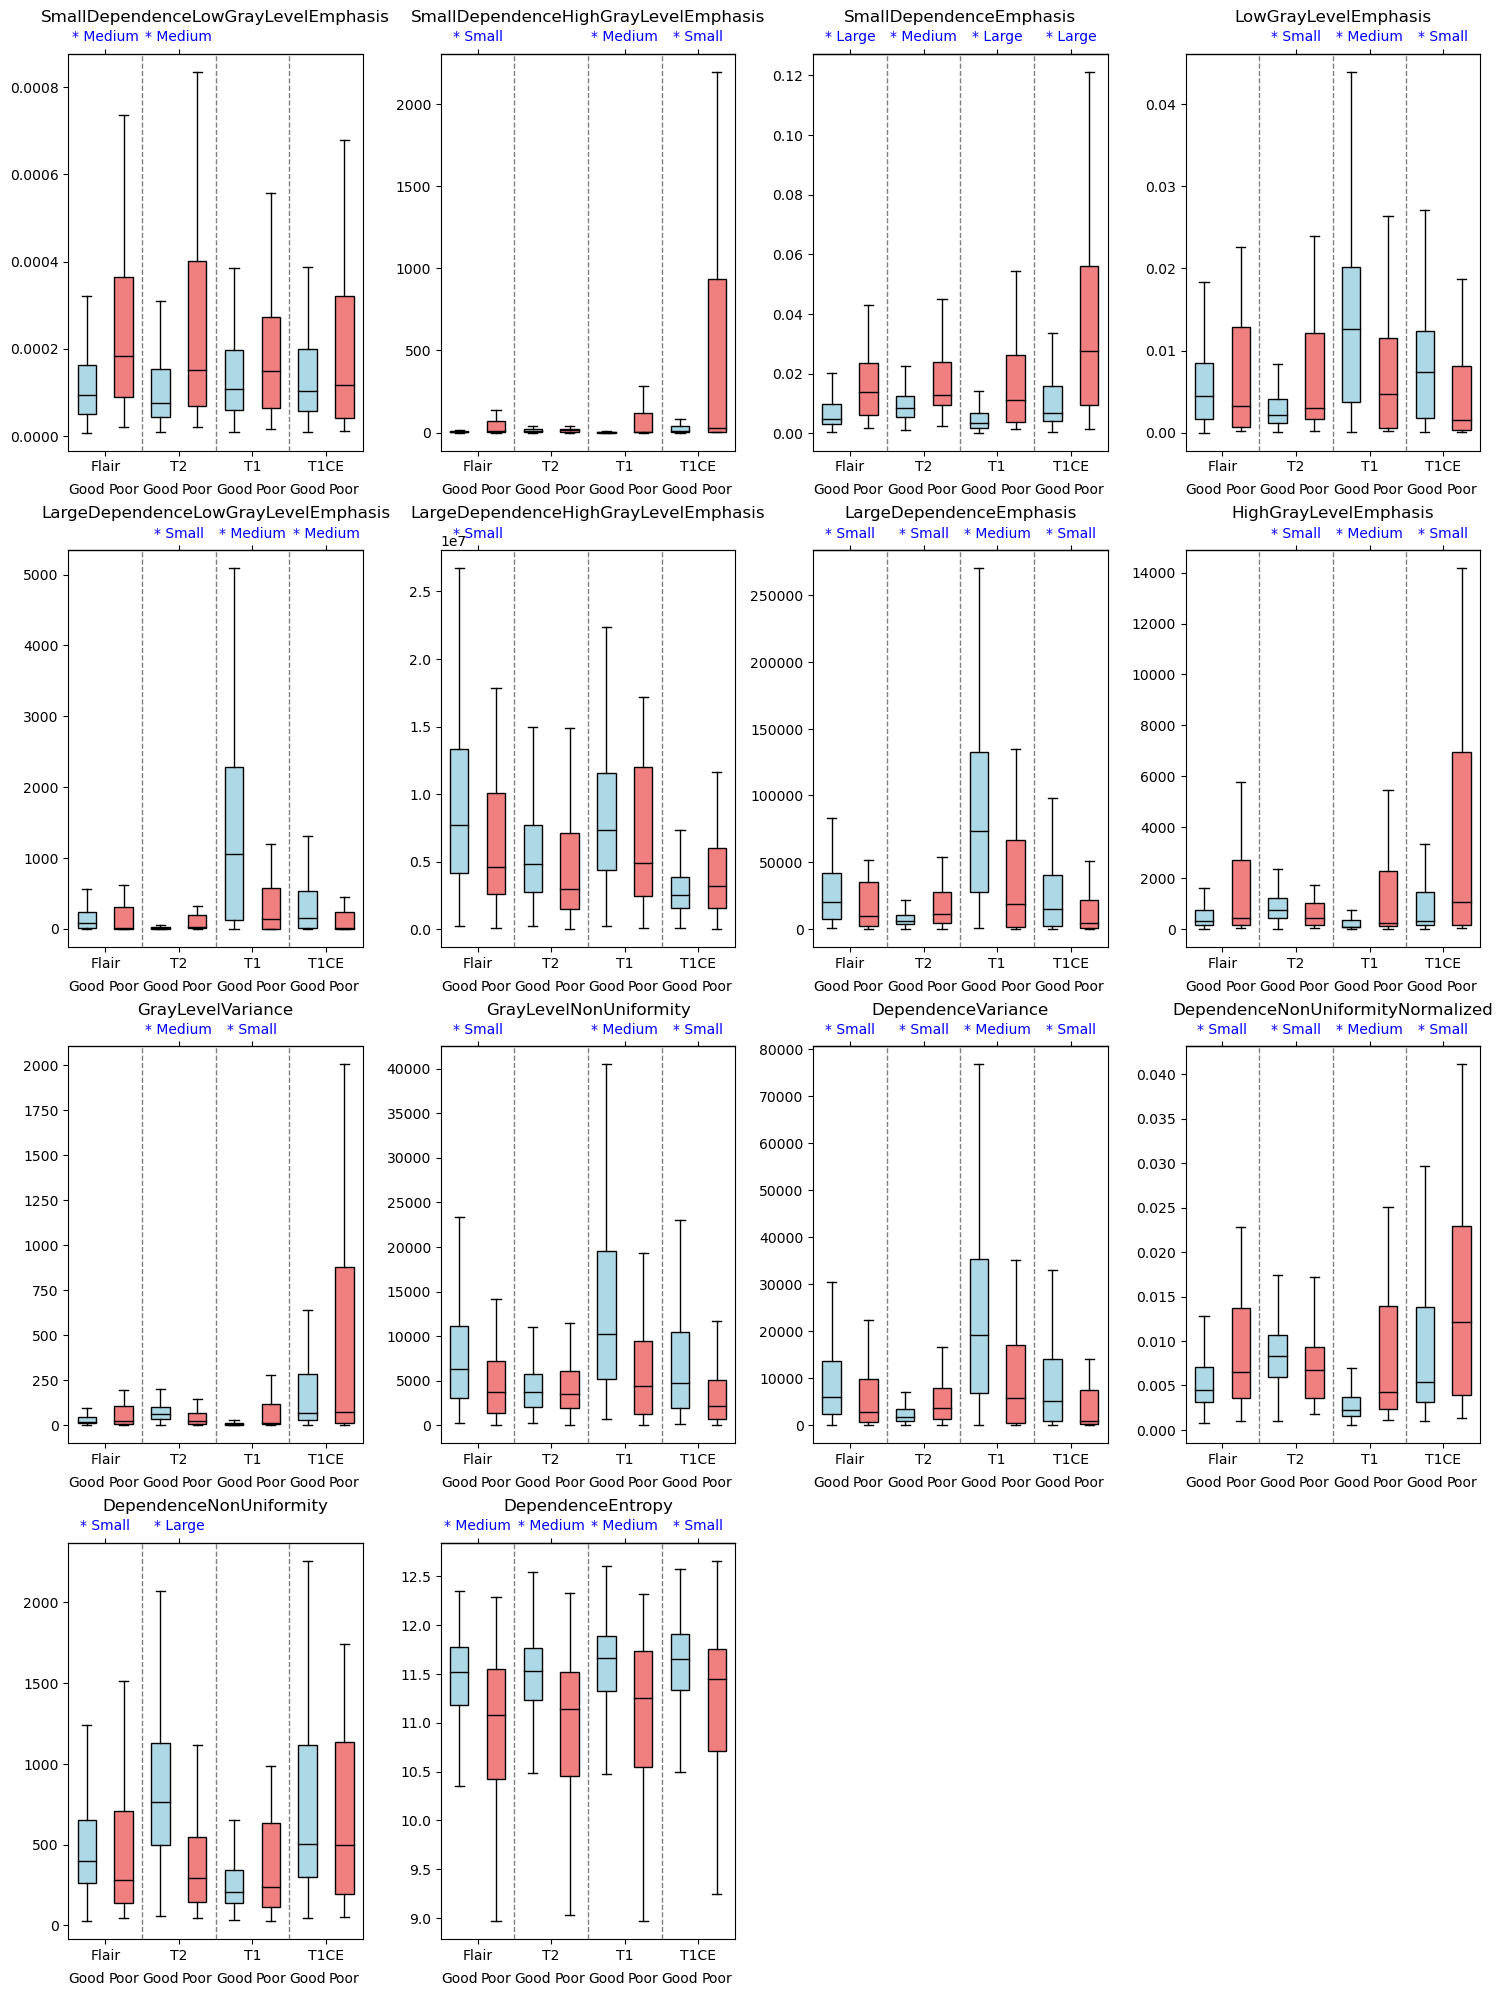

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from scipy.stats import mannwhitneyu
import numpy as np
import json

# Function to convert columns to numeric and skip those that can't be converted
def filter_numeric_columns(df):
    numeric_df = df.apply(pd.to_numeric, errors='coerce')
    return numeric_df.dropna(axis=1, how='all')

# Function to calculate Cliff's delta
def cliffs_delta(x, y):
    n_x = len(x)
    n_y = len(y)
    N_gr = sum(xi > yi for xi in x for yi in y)
    N_ls = sum(xi < yi for xi in x for yi in y)
    return (N_gr - N_ls) / (n_x * n_y)

# Function to categorize effect size based on Cliff's delta
def categorize_effect_size(delta):
    abs_delta = abs(delta)
    if abs_delta < 0.147:
        return 'No'
    elif 0.147 <= abs_delta < 0.33:
        return 'Small'
    elif 0.33 <= abs_delta < 0.474:
        return 'Medium'
    else:
        return 'Large'

# Function to add significance and effect size indicators as a separate xtick on top of the subplots
def add_significance_indicator(axes, data_good, data_bad, x_pos, alpha=0.05):
    # Perform Mann-Whitney U test
    stat, p_value = mannwhitneyu(data_good, data_bad)
    
    # Check if the result is significant
    if p_value < alpha:
        # Calculate Cliff's delta
        delta_value = cliffs_delta(data_good, data_bad)
        # Categorize effect size
        effect_size_category = categorize_effect_size(delta_value)
        
        # Create the label string with significance and effect size
        label = f"* {effect_size_category}"
        
        # Add the new label at the specified position on a secondary x-axis
        axes_secondary = axes.secondary_xaxis('top')
        axes_secondary.set_xticks([x_pos + 0.5])
        axes_secondary.set_xticklabels([label], rotation=0, ha='center')
        
        # Adjust the color of the labels
        for label in axes_secondary.get_xticklabels():
            text = label.get_text()
            if "*" in text:
                label.set_color('blue')  # Set color for significance

        # Optional: Adjust the label font size for visibility
        for label in axes_secondary.get_xticklabels():
            label.set_fontsize(10)
    
    return p_value, delta_value if p_value < alpha else None, effect_size_category if p_value < alpha else 'No'

# Filter the columns to keep only numeric ones
WT_unet_df_good_numeric = filter_numeric_columns(WT_unet_df_good)
WT_unet_df_bad_numeric = filter_numeric_columns(WT_unet_df_bad)
TC_unet_df_good_numeric = filter_numeric_columns(TC_unet_df_good)
TC_unet_df_bad_numeric = filter_numeric_columns(TC_unet_df_bad)
ET_unet_df_good_numeric = filter_numeric_columns(ET_unet_df_good)
ET_unet_df_bad_numeric = filter_numeric_columns(ET_unet_df_bad)

# Generate Feature Names
feature_names = []
for col in ET_results_df.columns[:-3]:
    col = col.split('_')[2]
    if col not in feature_names:
        feature_names.append(col)

# Define the number of rows and columns for the grid
n_cols = 4  # Number of columns per row in the grid
plots_per_figure = 16  # Number of plots per figure

# Colors for the box plots
colors = ['lightblue', 'lightcoral'] * 4  # Alternating colors for "Good" and "Bad" for each group

# Labels grouped by categories with "Good" and "Bad" sub-labels
group_labels = ['Flair', 'T2', 'T1', 'T1CE']
sub_labels = ['Good', 'Poor']

# Summary dictionary to store median, IQR, significance, and effect size data
summary_data = {}

# Open a PDF file to save the figures
with PdfPages("../Results/final_figures/GLDM.pdf") as pdf:
    # Generate the plots across multiple figures
    for fig_num in range(len(feature_names) // plots_per_figure + (len(feature_names) % plots_per_figure > 0)):
        start_idx = fig_num * plots_per_figure
        end_idx = min(start_idx + plots_per_figure, len(feature_names))
        
        fig, axes = plt.subplots((end_idx - start_idx) // n_cols + 1, n_cols, figsize=(15, 5 * ((end_idx - start_idx) // n_cols + 1)))
        # Flatten the axes array for easier indexing
        axes = axes.flatten()

        for i, col in enumerate(feature_names):
            summary_data[col] = {}  # Initialize dictionary for the current feature
            
            data_groups = [
                (WT_unet_df_good_numeric[f'original_gldm_{col}_flair_' + analysis_types[0]], 
                 WT_unet_df_bad_numeric[f'original_gldm_{col}_flair_' + analysis_types[0]]),
                (WT_unet_df_good_numeric[f'original_gldm_{col}_t2_' + analysis_types[0]], 
                 WT_unet_df_bad_numeric[f'original_gldm_{col}_t2_' + analysis_types[0]]),
                (WT_unet_df_good_numeric[f'original_gldm_{col}_t1_' + analysis_types[0]], 
                 WT_unet_df_bad_numeric[f'original_gldm_{col}_t1_' + analysis_types[0]]),
                (WT_unet_df_good_numeric[f'original_gldm_{col}_t1ce_' + analysis_types[0]], 
                 WT_unet_df_bad_numeric[f'original_gldm_{col}_t1ce_' + analysis_types[0]])
            ]
            
            box = axes[i].boxplot(
                [group_data for good, bad in data_groups for group_data in (good, bad)],
                patch_artist=True, 
                widths=0.5,
                showfliers=False  # Hide outliers
            )

            # Set colors for the box plot median
            for median in box['medians']:
                median.set_color('black')

            # Set colors for the box plots
            for patch, color in zip(box['boxes'], colors):
                patch.set_facecolor(color)

            # Add significance indicators and store summary data
            for j, (good, bad) in enumerate(data_groups):
                p_value, delta_value, effect_size = add_significance_indicator(axes[i], good, bad, 2 * j + 1)
                summary_data[col][group_labels[j]] = {
                    'median_good': np.median(good),
                    'iqr_good': np.percentile(good, 75) - np.percentile(good, 25),
                    'median_bad': np.median(bad),
                    'iqr_bad': np.percentile(bad, 75) - np.percentile(bad, 25),
                    'p_value': p_value,
                    'cliffs_delta': delta_value,
                    'effect_size': effect_size
                }

            # Set the x-axis with grouped labels
            axes[i].set_xticks([1.5, 3.5, 5.5, 7.5])
            axes[i].set_xticklabels(group_labels)

            # Add sub-labels under each group
            for j, x in enumerate([1, 2, 3, 4, 5, 6, 7, 8]):
                axes[i].text(
                    x, axes[i].get_ylim()[0] - (axes[i].get_ylim()[1] - axes[i].get_ylim()[0]) * 0.1, 
                    sub_labels[j % 2], ha='center', va='center', fontsize=10
                )

            # Add dotted lines to separate the groups
            for pos in [2.5, 4.5, 6.5]:
                axes[i].axvline(x=pos, color='gray', linestyle='--', linewidth=1)

            col_title = col
            axes[i].set_title(f'{col_title}')

        # Remove any empty subplots
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()

        # Save the current figure to the PDF
        pdf.savefig(fig)
        plt.show()
        plt.close(fig)  # Close the figure to free memory

    # The PDF will automatically be closed here when exiting the with block

# Save the summary data to a JSON file
with open('../Results/Json_summary/summary_gldm.json', 'w') as json_file:
    json.dump(summary_data, json_file, indent=4)
